In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
np.warnings = warnings

import torch
import random
import math
import sys
sys.path.append("../..")  # Add parent directory to path
sys.path.append("../../../..")
from simple_synth import SimpleSynth
import scipy
import matplotlib
import matplotlib.pyplot as plt


tensor([0.0622, 0.0415, 0.0371, 0.0340, 0.0335, 0.0414])
Iteration 1/20, Current best: 0.5190, 


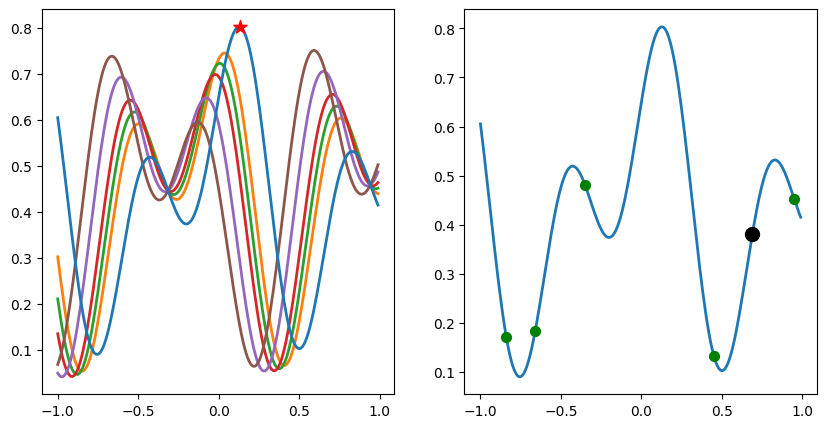

tensor([0.0937, 0.0349, 0.0298, 0.0253, 0.0254, 0.0357])
Iteration 2/20, Current best: 0.5190, 


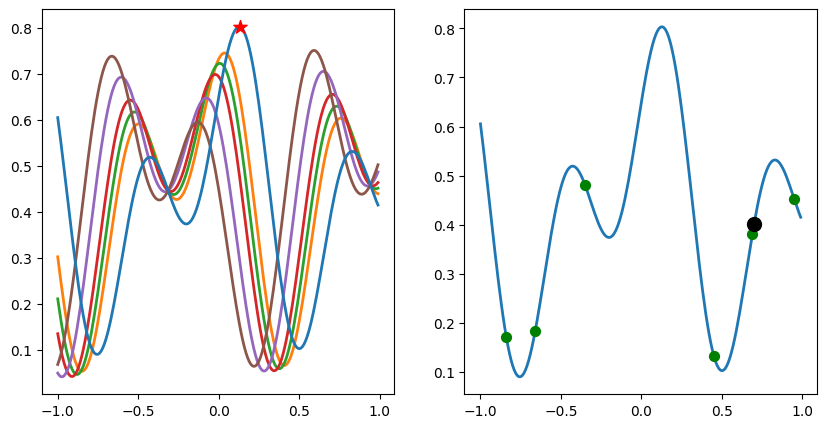

tensor([0.1339, 0.0286, 0.0240, 0.0217, 0.0208, 0.0286])
Iteration 3/20, Current best: 0.4917, 


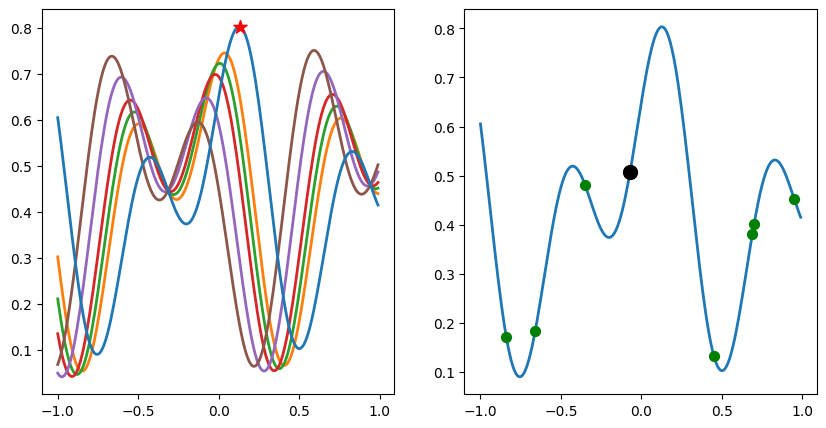

tensor([0.1121, 0.0260, 0.0211, 0.0202, 0.0182, 0.0256])
Iteration 4/20, Current best: 0.4917, 


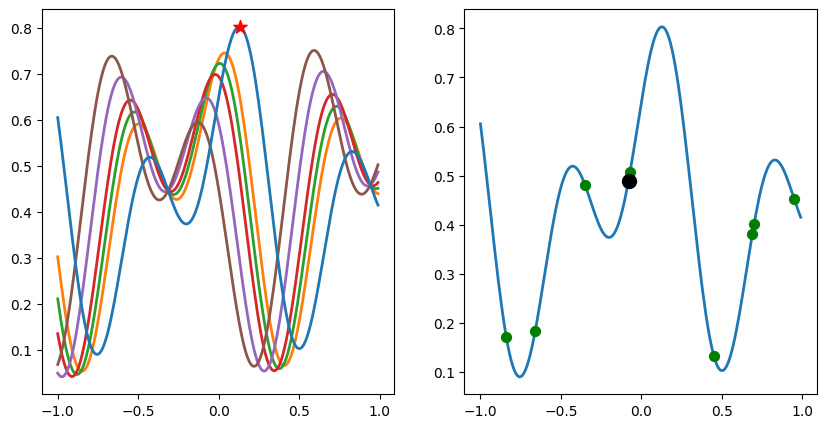

tensor([0.1464, 0.0211, 0.0186, 0.0178, 0.0163, 0.0211])
Iteration 5/20, Current best: 0.3909, 


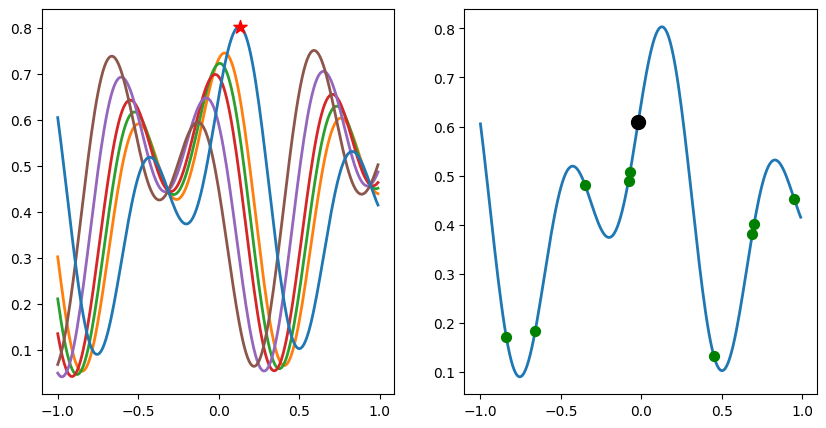

tensor([0.1217, 0.0217, 0.0171, 0.0167, 0.0167, 0.0156])
Iteration 6/20, Current best: 0.3302, 


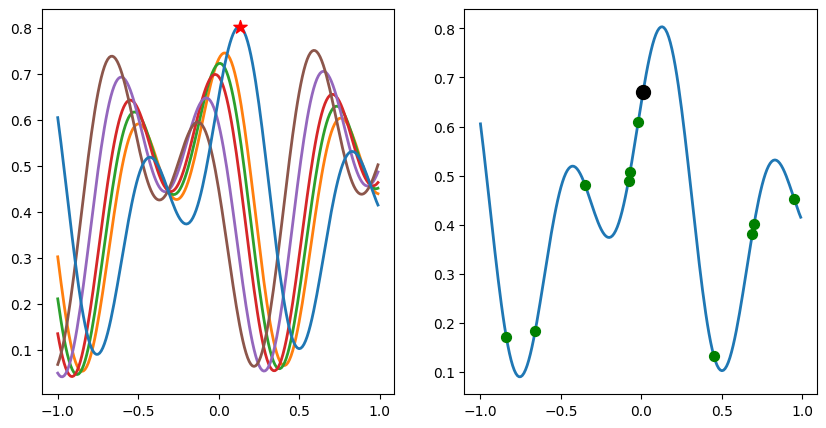

tensor([0.1222, 0.0201, 0.0169, 0.0158, 0.0156, 0.0115])
Iteration 7/20, Current best: 0.2928, 


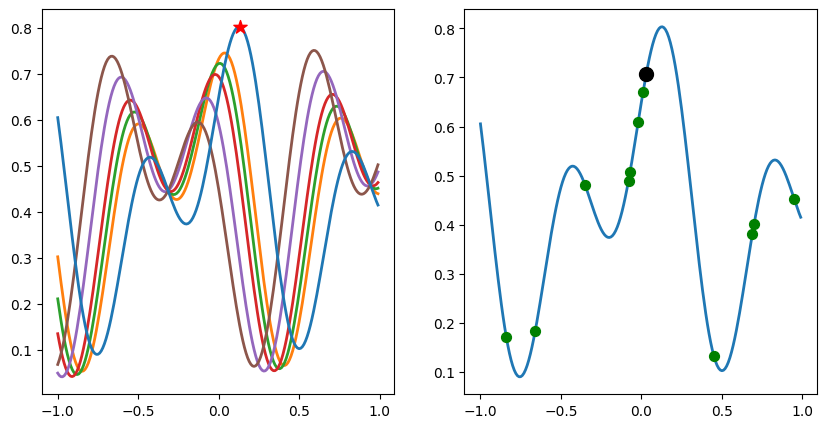

tensor([0.1301, 0.0202, 0.0158, 0.0152, 0.0143, 0.0070])
Iteration 8/20, Current best: 0.2598, 


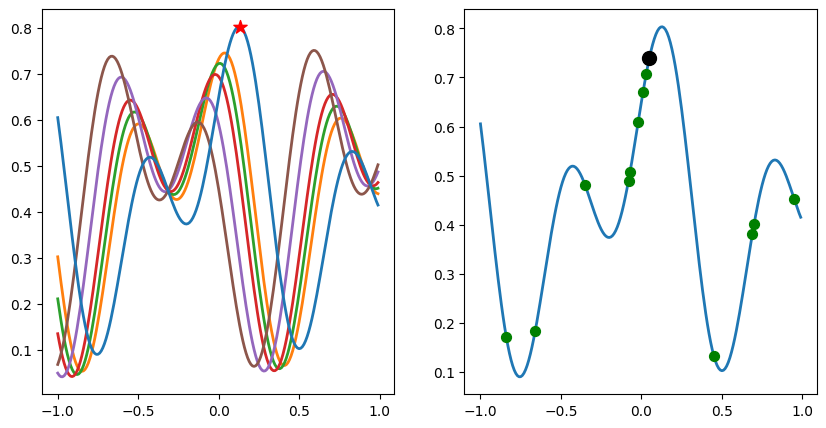

tensor([0.1515, 0.0176, 0.0156, 0.0139, 0.0136, 0.0045])
Iteration 9/20, Current best: 0.2326, 


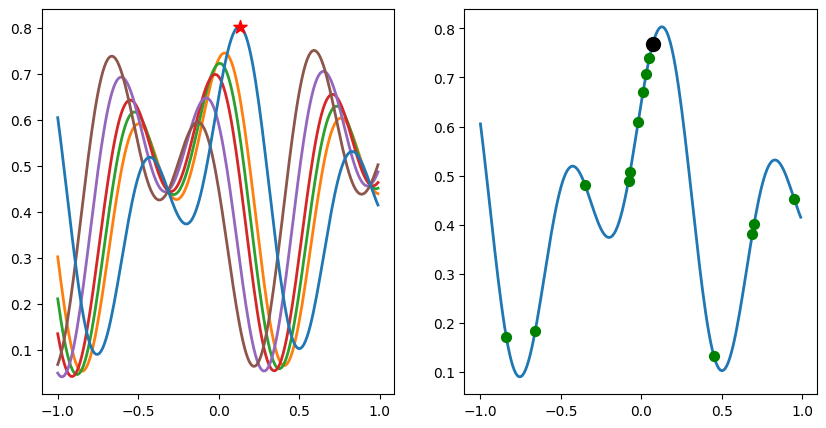

tensor([0.1639, 0.0163, 0.0143, 0.0132, 0.0127, 0.0031])
Iteration 10/20, Current best: 0.2123, 


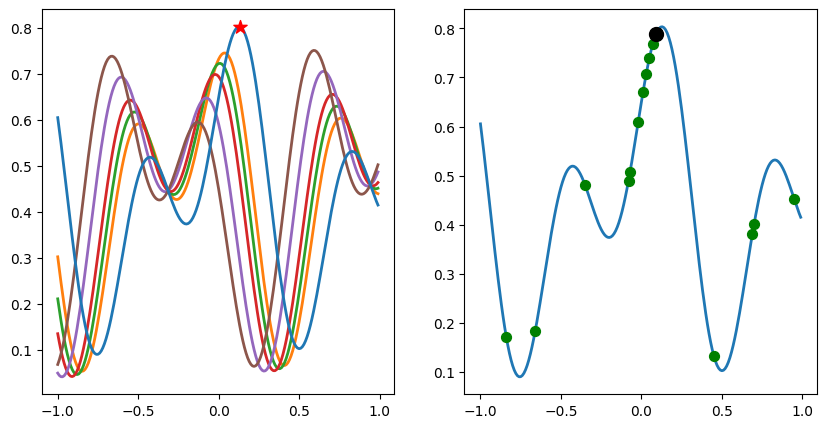

tensor([0.1682, 0.0150, 0.0134, 0.0123, 0.0123, 0.0025])
Iteration 11/20, Current best: 0.2002, 


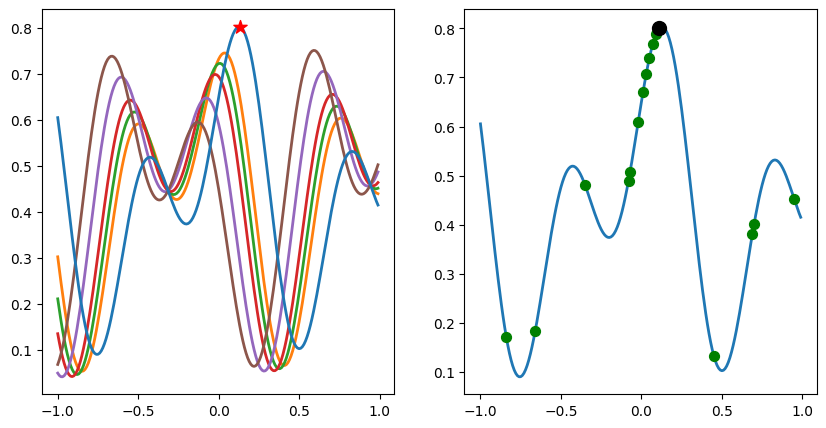

tensor([0.1684, 0.0147, 0.0125, 0.0123, 0.0110, 0.0015])
Iteration 12/20, Current best: 0.1973, 


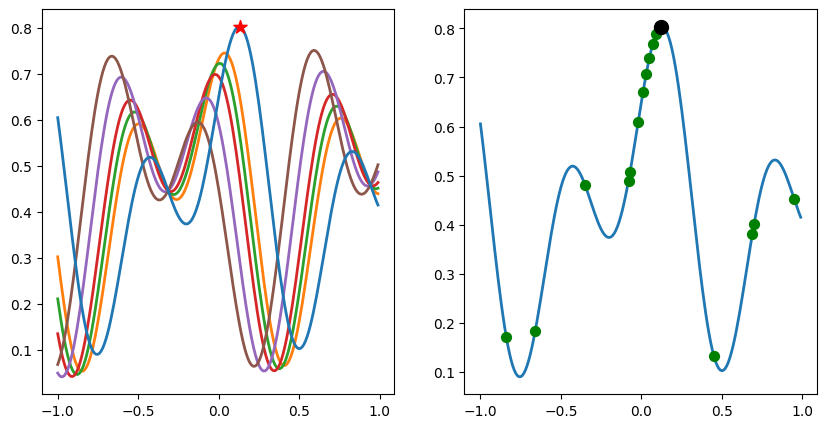

tensor([0.1757, 0.0143, 0.0127, 0.0118, 0.0084, 0.0012])
Iteration 13/20, Current best: 0.1968, 


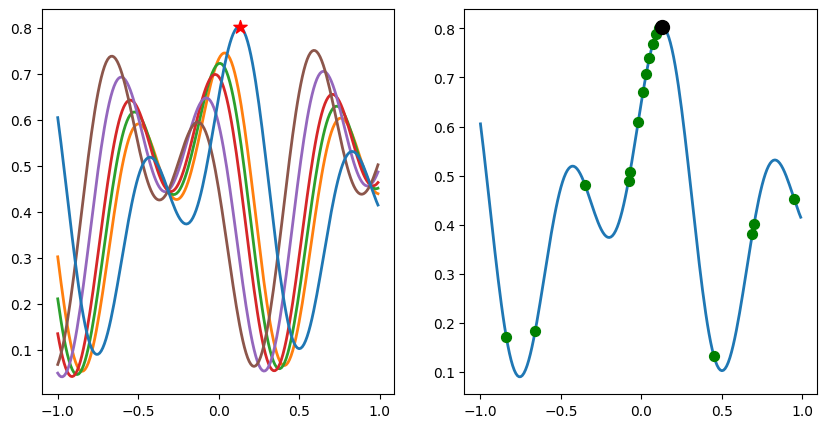

In [11]:
test_seed = "test1"
task_id = 0  # Task ID for the SimpleSynth benchmark
max_evaluations = 20

benchmark = SimpleSynth(seed=test_seed, start_task=task_id, initializations=5)


fontsize = 18
lw=2

import pfns4bo
from mpfns4bo.mpfns4bo import MPFNs4BO
meta_data = benchmark.get_meta_data(task_ids=[3, 4, 5, 7, 9])
optimizer = MPFNs4BO(torch.load( pfns4bo.hebo_plus_model), benchmark.search_space, meta_data, apply_power_transform=False,
                    apply_power_transform_pi=True,
                    only_obs_incumbents=True, tranformation_type=None, mixing_strategy="my",)




X = np.asarray(benchmark.benchmark_data["X"])
y = np.asarray(benchmark.benchmark_data["y"])
y = 1 - y

data_size = len(X)
# indices of pending evaluations
pending_evaluations = list(range(data_size))
current_evaluations = []

init_ids = benchmark.bo_initializations[test_seed]
for i in range(len(init_ids)):
    idx = init_ids[i]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)


min_regret_history = [np.min(y[current_evaluations])]
opt_time = []
for iteration in range(max_evaluations):
    fig, axs = plt.subplots(1,2, figsize=(10,5))

    
    not_init = np.setdiff1d(np.arange(data_size), init_ids)
    axs[0].plot(X[not_init], 1 - y[not_init], linewidth=lw, label="\textbf{Down Stream Task}", zorder = 99)

    task_names = ["Meta-Train Task 1", "Meta-Train Task 2", "Meta-Train Task 3", "Meta-Train Task 4", "Meta-Train Task 5"]

    for i, (k, mdata) in enumerate(meta_data.items()):
        mX = np.array([benchmark.search_space.to_numerical(e.configuration) for e in mdata])
        mY = - np.array([e.objectives["loss"] for e in mdata]).reshape(-1) # return to maximization (performance)
        sort_idx = np.argsort(mX.flatten())
        axs[0].plot(mX[sort_idx], mY[sort_idx], linewidth=lw, label=task_names[i])


    axs[0].scatter([X[y.argmin()]], [1 - y.min()], marker="*", s=100, c= "red", zorder = 99)

    not_evaluated = np.setdiff1d(np.arange(data_size), current_evaluations)
    axs[1].plot(X[not_evaluated], 1 - y[not_evaluated], linewidth=lw, label="\textbf{Down Stream Task}", zorder = 99)
    axs[1].scatter(X[current_evaluations], 1 - y[current_evaluations], s= 50, c= "green", label="Observed Samples", zorder = 99)
    idx = optimizer.observe_and_suggest(
        X[current_evaluations], y[current_evaluations], X[pending_evaluations]
    )

    axs[1].scatter(X[pending_evaluations][idx], 1 - y[pending_evaluations][idx], s= 100, c= "black", label="Next Sample (with meta learning)", zorder = 99)
    idx = pending_evaluations[idx]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)
    min_regret_history.append(np.min(y[current_evaluations]))

    print(optimizer.pfnimputation.reliability_scores)

    print(f"Iteration {iteration + 1}/{max_evaluations}, "
            f"Current best: {min_regret_history[-1]:.4f}, ")

    plt.show()


    if min(y) in min_regret_history:
        break

# negate to recover accuracy
min_regret_history += [min(y).item()] * (max_evaluations - i - 1)